# TP2: Análisis Exploratorio y Curación de Datos

Autores: Ana Paula Cobresí, Gonzalo Angaut, Javier Albiero y Octavio Santi.

## Introducción

Segundo trabajo práctico de la mentoría «Predicciones en el Espacio: ¿Cuántos satélites y desechos podremos tener?». Integramos el catálogo de objetos espaciales con UCS, revisamos la calidad de los datos y preparamos conjuntos reproducibles para el aprendizaje supervisado y la exploración no supervisada.

El objetivo supervisado es estimar la **vida útil esperada informada por UCS** a partir de atributos del satélite. No equivale al tiempo hasta reentrada ni permite, por sí solo, proyectar la población futura en órbita. Sólo los registros con esa etiqueta disponible participan en entrenamiento, validación y prueba. Las filas sin etiqueta se conservan para análisis posteriores.

Las transformaciones que aprenden estadísticas se ajustan con entrenamiento. Los CSV se exportan **antes de imputar, codificar y escalar**, para poder repetir ese ajuste dentro de cada fold de validación cruzada en TP3.


Usamos los cuatro JSON (`satellites.json`, `debris.json`, `rockets.json`, `unknown.json`) y `ucs-satellite-database.xlsx` de una [versión fija del repositorio de datos](https://github.com/EnzoRg/space_debris/tree/1c49c73b92e84d3eba2c53f43313ed861d08f896/data/raw).

Los JSON comparten estructura; UCS aporta atributos de misión, órbita, masa y vida útil esperada. Cada fila representa un objeto catalogado. Las fuentes pueden tener diferentes fechas de corte y discrepancias de clasificación. La fecha del commit fija una versión, no una fecha común de observación.

Referencias: [UCS](https://www.ucs.org/resources/satellite-database), [órbitas — ESA](https://www.esa.int/Enabling_Support/Space_Transportation/Types_of_orbits) y [prevención de data leakage — scikit-learn](https://scikit-learn.org/stable/common_pitfalls.html#data-leakage).


## Inspección de los datos

Importamos las librerías necesarias para el análisis y visualización de los datos.

In [1]:
%matplotlib inline

import hashlib
import json
import sys
from pathlib import Path
from urllib.request import urlretrieve

import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from IPython.display import display
from pandas import Series
from sklearn.model_selection import train_test_split

# La notebook puede abrirse desde esta carpeta o desde la raíz del repositorio.
candidates = [Path.cwd(), Path.cwd() / 'Mentorias' / 'AEyCD', Path.cwd().parent / 'AEyCD']
PROJECT_DIR = next((path for path in candidates if (path / 'preprocessing.py').is_file()), None)
if PROJECT_DIR is None:
    raise FileNotFoundError('Abrir desde el repositorio o colocar preprocessing.py junto a la notebook.')
sys.path.insert(0, str(PROJECT_DIR))
from preprocessing import FEATURE_COLUMNS, NUMERIC_MEDIAN_FEATURES, TARGET, make_preprocessor

RANDOM_SEED = 42
pd.options.mode.copy_on_write = True
pd.options.display.max_columns = None
sns.set_theme(style='whitegrid', context='notebook')


No event loop hook running.


Comencemos leyendo los archivos y mostrando las primeras filas para visualizar la forma de los datos.

In [2]:
DATA_COMMIT = '1c49c73b92e84d3eba2c53f43313ed861d08f896'
DATA_URL = f'https://raw.githubusercontent.com/EnzoRg/space_debris/{DATA_COMMIT}/data/raw'
DATA_DIR = PROJECT_DIR / 'data' / 'raw' / DATA_COMMIT
DATA_DIR.mkdir(parents=True, exist_ok=True)
EXPECTED_SHA256 = {'debris.json': '8b6043f38307048da392c266c783702ea741a1aeb2d973e823a799b709d47ac7', 'rockets.json': '38048acc6272aeabd57a0554b752122933067dc088acc02666fcd9700a0b040b', 'satellites.json': 'aa008e5ddaecb1c638758225bc7592762a92f5b7a5bd706a4d083771ebd3607d', 'ucs-satellite-database.xlsx': '337ec8c8c0ec7bf45a7e8b61842a80688ae5124bfb3cf3f9a4ef2cfee134aae5', 'unknown.json': '6837e556a4c08e71b4679e272ae7a3ef86b4a9c1bb63e2248a3d3a6f48bc0377'}

for filename, expected_hash in EXPECTED_SHA256.items():
    destination = DATA_DIR / filename
    if not destination.exists():
        temporary = destination.with_suffix(destination.suffix + '.part')
        urlretrieve(f'{DATA_URL}/{filename}', temporary)
        if hashlib.sha256(temporary.read_bytes()).hexdigest() != expected_hash:
            temporary.unlink()
            raise ValueError(f'Contenido inesperado en {filename}')
        temporary.replace(destination)
    if hashlib.sha256(destination.read_bytes()).hexdigest() != expected_hash:
        raise ValueError(f'El archivo local {filename} no coincide con la fuente fijada.')

satellites_df = pd.read_json(DATA_DIR / 'satellites.json')
debris_df = pd.read_json(DATA_DIR / 'debris.json')
rockets_df = pd.read_json(DATA_DIR / 'rockets.json')
unknown_df = pd.read_json(DATA_DIR / 'unknown.json')
extra_data_df = pd.read_excel(DATA_DIR / 'ucs-satellite-database.xlsx')
satellites_df.head(3)


Out[2]: 
     INTLDES  NORAD_CAT_ID OBJECT_TYPE     SATNAME COUNTRY      LAUNCH   SITE  \
0  1958-001A             4     PAYLOAD  EXPLORER 1      US  1958-02-01  AFETR   
1  1958-003A             6     PAYLOAD  EXPLORER 3      US  1958-03-26  AFETR   
2  1958-004B             8     PAYLOAD   SPUTNIK 3     CIS  1958-05-15  TTMTR   

        DECAY  PERIOD  INCLINATION  APOGEE  PERIGEE COMMENT  COMMENTCODE  \
0  1970-03-31   88.48        33.15   215.0    183.0    None          NaN   
1  1958-06-28  103.60        33.50  1739.0    117.0    None          5.0   
2  1960-04-06   88.43        65.06   255.0    139.0    None          NaN   

   RCSVALUE RCS_SIZE  FILE  LAUNCH_YEAR  LAUNCH_NUM LAUNCH_PIECE CURRENT  \
0         0     None     1         1958           1            A       Y   
1         0     None     1         1958           3            A       Y   
2         0    LARGE     1         1958           4            B       Y   

  OBJECT_NAME  OBJECT_ID  OBJECT_NUMBER  
0  EXPLORER 1 

In [3]:
# O las primeras columnas del debris
debris_df[:3]

Out[3]: 
     INTLDES  NORAD_CAT_ID OBJECT_TYPE            SATNAME COUNTRY      LAUNCH  \
0  1960-003C            33      DEBRIS  THOR ABLESTAR DEB      US  1960-04-13   
1  1960-005D            37      DEBRIS      SPUTNIK 4 DEB     CIS  1960-05-15   
2  1960-005E            38      DEBRIS      SPUTNIK 4 DEB     CIS  1960-05-15   

    SITE       DECAY  PERIOD  INCLINATION  APOGEE  PERIGEE COMMENT  \
0  AFETR  1960-07-17   93.59        51.29   615.0    285.0    None   
1  TTMTR  1961-06-30   92.92        64.89   552.0    282.0    None   
2  TTMTR  1960-08-20   90.63        64.89   328.0    282.0    None   

   COMMENTCODE  RCSVALUE RCS_SIZE  FILE  LAUNCH_YEAR  LAUNCH_NUM LAUNCH_PIECE  \
0          NaN         0     None     1         1960           3            C   
1          NaN         0     None     1         1960           5            D   
2          NaN         0     None     1         1960           5            E   

  CURRENT        OBJECT_NAME  OBJECT_ID  OBJECT_NUMBER  
0  

### Unificación de los _datasets_

Como todos tienen la misma estructura, y el tipo de objeto puede saberse desde 'OBJECT_TYPE', podemos concatenarlos en un solo DataFrame.

In [4]:
# Veamos que cada archivo tenga su propio OBJECT_TYPE
print(satellites_df.OBJECT_TYPE.unique())
print(debris_df.OBJECT_TYPE.unique())
print(rockets_df.OBJECT_TYPE.unique())
print(unknown_df.OBJECT_TYPE.unique())

['PAYLOAD']
['DEBRIS']
['ROCKET BODY']
['UNKNOWN']


In [5]:
# Los concatenamos en un solo DataFrame
space_objects_df = pd.concat([satellites_df, debris_df, rockets_df, unknown_df], ignore_index=True)

# Vemos el dataframe
space_objects_df.sample(5, random_state=RANDOM_SEED)

Out[5]: 
         INTLDES  NORAD_CAT_ID  OBJECT_TYPE        SATNAME COUNTRY  \
1786   1990-069A         20732      PAYLOAD    COSMOS 2089     CIS   
11524  2022-101S         53543      PAYLOAD  STARLINK-4297      US   
56130  1966-092C          2505  ROCKET BODY    SL-6 R/B(1)     CIS   
5068   2007-013A         31135      PAYLOAD          AGILE      IT   
53035  2015-075H         41547       DEBRIS   BREEZE-M DEB     CIS   

           LAUNCH   SITE       DECAY   PERIOD  INCLINATION   APOGEE  PERIGEE  \
1786   1990-08-03  PKMTR  1990-10-01    88.72        62.82    257.0    165.0   
11524  2022-08-19  AFETR        None    95.44        53.22    541.0    539.0   
56130  1966-10-20  TTMTR  1966-11-02    90.40        64.80    390.0    195.0   
5068   2007-04-23    SRI  2024-02-13    88.44         2.46    199.0    195.0   
53035  2015-12-13  TTMTR        None  1395.48         7.66  36071.0  33904.0   

      COMMENT  COMMENTCODE  RCSVALUE RCS_SIZE  FILE  LAUNCH_YEAR  LAUNCH_NUM  \
1786     

In [6]:
assert sum(len(df) for df in [satellites_df, debris_df, rockets_df, unknown_df]) == len(space_objects_df)
assert space_objects_df['NORAD_CAT_ID'].notna().all()
assert space_objects_df['NORAD_CAT_ID'].is_unique
print(f'Objetos catalogados: {len(space_objects_df):,}')


Objetos catalogados: 63,521


## Integración y selección de la población

### Atributos orbitales y de misión

`RCS_SIZE` es una categoría de sección radar, no una medida directa de diámetro o masa. UCS aporta `Class of Orbit` (LEO, MEO, GEO, etc.), `Type of Orbit` y características de misión. La unión se realiza por identificador NORAD y su cobertura se comprueba antes de seleccionar la población.


In [7]:
extra_data_df[:3]

Out[7]: 
                  Name of Satellite, Alternate Names  \
0  1HOPSAT-TD (1st-generation High Optical Perfor...   
1                            AAC AIS-Sat1 (Kelpie 1)   
2                                           Aalto-1    

  Current Official Name of Satellite Country/Org of UN Registry  \
0                         1HOPSAT-TD                         NR   
1            AAC AIS-Sat1 (Kelpie 1)             United Kingdom   
2                            Aalto-1                    Finland   

  Country of Operator/Owner    Operator/Owner       Users  \
0                       USA      Hera Systems  Commercial   
1            United Kingdom   AAC Clyde Space  Commercial   
2                   Finland  Aalto University       Civil   

                  Purpose                       Detailed Purpose  \
0       Earth Observation                       Infrared Imaging   
1       Earth Observation  Automatic Identification System (AIS)   
2  Technology Development                       

Combinamos las fuentes mediante `NORAD_CAT_ID` en el catálogo y `NORAD Number` en UCS. Primero comprobamos unicidad y resolvemos los identificadores duplicados.


In [8]:
space_objects_df['NORAD_CAT_ID'].sample(5, random_state=RANDOM_SEED)

Out[8]: 
1786     20732
11524    53543
56130     2505
5068     31135
53035    41547
Name: NORAD_CAT_ID, dtype: int64


In [9]:
extra_data_df['NORAD Number'].sample(5, random_state=RANDOM_SEED)

Out[9]: 
6882    56035
6237    53913
263     55011
694     45608
2264    49285
Name: NORAD Number, dtype: int64


Antes de unir los dataframes (o agregar las columnas relevantes de extra_data a satellites, etc) veamos que los identificadores son realmente únicos.

In [10]:
print("Duplicados en space objects: ", space_objects_df['NORAD_CAT_ID'].duplicated().sum())
print("Duplicados en extra_data: ", extra_data_df['NORAD Number'].duplicated().sum())

Duplicados en space objects:  0
Duplicados en extra_data:  9


Notemos que el único que contiene identificadores duplicados es `extra_data_df`. Por ende, antes de unirlos, exploremos como son estos datos.

In [11]:
# Cantidad de filas totalmente duplicadas (incluyendo NORAD Number y demás)
exact_duplicates = extra_data_df.duplicated()
exact_duplicates.sum()

Out[11]: np.int64(7)


Hay 7 filas que están completamente duplicadas. Por lo tanto, podemos eliminar los duplicados y quedarnos unicamente con 1 de esos.

In [12]:
extra_data_clean_df = extra_data_df.drop_duplicates()
extra_data_clean_df['NORAD Number'].duplicated().sum()

Out[12]: np.int64(2)


Quedan 2 filas que tienen el mismo 'NORAD Number' pero no estan completamente duplicados. Veamos estas.

In [13]:
# Veamos los NORAD Numbers que siguen estando duplicados en extra_data_clean
remaining_dupes = extra_data_clean_df['NORAD Number'][extra_data_clean_df['NORAD Number'].duplicated()].unique()

# Vemos los nombres de los satelites en esos NORAD Numbers
space_obj_names_df = space_objects_df[space_objects_df['NORAD_CAT_ID'].isin(remaining_dupes)][['NORAD_CAT_ID', 'SATNAME']]
print(space_obj_names_df)

# Vemos los nombres de los extra_data_clean en los duplicados
extra_dupes_df = extra_data_clean_df[extra_data_clean_df['NORAD Number'].isin(remaining_dupes)][
    ['NORAD Number', 'Name of Satellite, Alternate Names']
]
print(extra_dupes_df)

       NORAD_CAT_ID        SATNAME
11757         54766  STARLINK-5471
11826         55455  STARLINK-5680
      NORAD Number Name of Satellite, Alternate Names
6621         54766                     Starlink-5471 
6622         54766                     Starlink-5472 
6744         55455      Starlink-5636                
6787         55455      Starlink-5680                


Para los dos identificadores en conflicto conservamos la fila cuyo nombre coincide con `SATNAME`, ignorando espacios laterales. La regla resuelve estos duplicados; no valida por sí sola todos los atributos de UCS.


In [14]:
# Creamos un diccionario de NORAD: nombre correcto
norad_correct_names = {
    54766: 'Starlink-5471',
    55455: 'Starlink-5680',
}

def keep_if_name_matches(row: Series) -> bool:
    """
    Función para filtrar las filas correctas
    """
    norad = row['NORAD Number']
    name = str(row['Name of Satellite, Alternate Names']).strip()

    # Si la fila tiene NORAD que aparece duplicado
    if norad in norad_correct_names:
        # Devolvemos el nombre correcto
        return name == norad_correct_names[norad]

    return True  # no es un NORAD conflictivo, lo dejamos

# Aplicamos el filtro
final_extra_data_df = extra_data_clean_df[extra_data_clean_df.apply(keep_if_name_matches, axis=1)]

# Chequeamos que ahora no haya duplicados en el final_extra_data
print("Duplicados en final_extra_data: ", final_extra_data_df['NORAD Number'].duplicated().sum())

Duplicados en final_extra_data:  0


Validamos que la tabla UCS tenga una sola fila por identificador antes de unir las fuentes.


Incorporamos clase y tipo de órbita, propósito, vida útil esperada, país del operador, usuarios y masa al lanzamiento. Conservamos la distinción entre país de registro y país del operador: no son necesariamente equivalentes. La selección de predictores se explicita más adelante.


In [15]:
relevant_cols_and_new_names = {
    'NORAD Number': 'NORAD_NUMBER', 'Class of Orbit': 'CLASS_OF_ORBIT',
    'Type of Orbit': 'TYPE_OF_ORBIT', 'Purpose': 'PURPOSE',
    'Expected Lifetime (yrs.)': 'EXPECTED_LIFETIME_YRS',
    'Country of Operator/Owner': 'COUNTRY_OF_OPERATOR_OWNER',
    'Users': 'USERS', 'Launch Mass (kg.)': 'LAUNCH_MASS_KG',
}
final_extra_data_small_df = final_extra_data_df[list(relevant_cols_and_new_names)].rename(columns=relevant_cols_and_new_names)
assert final_extra_data_small_df['NORAD_NUMBER'].is_unique
matched_df = space_objects_df.merge(
    final_extra_data_small_df, how='inner', left_on='NORAD_CAT_ID',
    right_on='NORAD_NUMBER', validate='one_to_one',
)
coverage = matched_df.groupby('OBJECT_TYPE').agg(
    Coincidencias=('NORAD_CAT_ID', 'size'), Vida_util_informada=(TARGET, 'count')
)
display(coverage)
space_objects_full_df = matched_df.loc[matched_df['OBJECT_TYPE'].eq('PAYLOAD')].copy()
space_objects_full_df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 7369 entries, 0 to 7368
Data columns (total 32 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   INTLDES                    7369 non-null   object 
 1   NORAD_CAT_ID               7369 non-null   int64  
 2   OBJECT_TYPE                7369 non-null   object 
 3   SATNAME                    7369 non-null   object 
 4   COUNTRY                    7369 non-null   object 
 5   LAUNCH                     7369 non-null   object 
 6   SITE                       7369 non-null   object 
 7   DECAY                      1438 non-null   object 
 8   PERIOD                     7326 non-null   float64
 9   INCLINATION                7326 non-null   float64
 10  APOGEE                     7326 non-null   float64
 11  PERIGEE                    7326 non-null   float64
 12  COMMENT                    37 non-null     object 
 13  COMMENTCODE                13 non-null     float64
 1

,Coincidencias,Vida_util_informada
OBJECT_TYPE,,
DEBRIS,15,1
PAYLOAD,7369,5428
ROCKET BODY,7,3
UNKNOWN,160,9


La coincidencia en un `inner join` no garantiza que el catálogo clasifique el objeto como satélite. Seleccionamos explícitamente los registros `PAYLOAD` con coincidencia UCS. Las coincidencias DEBRIS, ROCKET BODY y UNKNOWN quedan fuera de la población de modelado y se cuantifican en la tabla anterior.

PAYLOAD tampoco garantiza actividad operativa. El alcance es este subconjunto del catálogo histórico, con cobertura condicionada por UCS; no representa todos los satélites ni todos los objetos espaciales.


In [16]:
population_summary = pd.Series({
    'Catálogo completo': len(space_objects_df),
    'Coincidencias UCS': len(matched_df),
    'PAYLOAD con coincidencia UCS': len(space_objects_full_df),
    'Otros tipos con coincidencia UCS': len(matched_df) - len(space_objects_full_df),
}, name='Registros').to_frame()
display(population_summary)


,Registros
Catálogo completo,63521
Coincidencias UCS,7551
PAYLOAD con coincidencia UCS,7369
Otros tipos con coincidencia UCS,182


## Reporte exploratorio inicial de los datos

Resumimos cobertura, tipos y faltantes. Este diagnóstico no ajusta transformaciones para el modelo. Las distribuciones y decisiones de preprocesamiento se estudian sobre entrenamiento después de separar los conjuntos.

In [17]:
def data_summary(frame):
    """Resumen tabular de tipos, cobertura y valores distintos."""
    return pd.DataFrame({
        'Tipo': frame.dtypes.astype(str), 'Informados': frame.notna().sum(),
        'Faltantes': frame.isna().sum(), 'Faltantes (%)': frame.isna().mean().mul(100).round(2),
        'Valores distintos': frame.nunique(),
    })

def save_report(title, tables, filename, note):
    """Guarda un reporte HTML liviano, sin dependencias de profiling."""
    from html import escape
    parts = [f'<!doctype html><html lang="es"><meta charset="utf-8"><title>{escape(title)}</title>',
             '<style>body{font:15px sans-serif;max-width:1200px;margin:40px auto;color:#213547}table{border-collapse:collapse;font-size:13px}th,td{padding:7px;border:1px solid #ddd}th{background:#e8eff5}</style>',
             f'<h1>{escape(title)}</h1><p>{escape(note)}</p>']
    for heading, table in tables.items():
        parts += [f'<h2>{escape(heading)}</h2>', table.to_html()]
    (PROJECT_DIR / filename).write_text('\n'.join(parts) + '</html>', encoding='utf-8')

initial_summary = data_summary(space_objects_full_df)
display(initial_summary)
save_report('TP2 — Reporte exploratorio inicial',
            {'Población': population_summary, 'Coincidencias por tipo': coverage, 'Atributos PAYLOAD': initial_summary},
            'TP2_ReporteExploratorioDeDatosInicial.html',
            'Catálogo histórico y UCS fijados por commit. Conteos descriptivos anteriores al preprocesamiento.')

,Tipo,Informados,Faltantes,Faltantes (%),Valores distintos
INTLDES,object,7369,0,0.00,7369
NORAD_CAT_ID,int64,7369,0,0.00,7369
OBJECT_TYPE,object,7369,0,0.00,1
SATNAME,object,7369,0,0.00,7369
COUNTRY,object,7369,0,0.00,91
LAUNCH,object,7369,0,0.00,1188
SITE,object,7369,0,0.00,26
DECAY,object,1438,5931,80.49,582
PERIOD,float64,7326,43,0.58,1230
INCLINATION,float64,7326,43,0.58,820


## Curación de datos

### Limpieza y normalización

Seleccionamos diez predictores: período, inclinación, apogeo, perigeo, año de lanzamiento, masa, categoría radar, país de registro, propósito y clase orbital. Los nombres e identificadores se guardan con prefijo `INFO_` para trazabilidad; nunca se usan como predictores.

Las fechas de lanzamiento y reentrada, el país del operador, usuarios y tipo orbital también se conservan como metadatos. El estado «sin reentrada registrada» no significa «operativo». No usamos `CURRENT` ni un tiempo calculado hasta la fecha de ejecución como predictores. La vida útil esperada no se imputa ni escala.

Aplicamos reglas de dominio fijas: período, masa y vida útil deben ser positivos; alturas no negativas; inclinación entre 0° y 180°. Los valores inválidos se marcan como faltantes y se cuentan. No se eliminan filas por percentiles.

In [18]:
metadata_names = {
    'SATNAME': 'INFO_SATNAME', 'NORAD_CAT_ID': 'INFO_NORAD_NUMBER',
    'OBJECT_TYPE': 'INFO_OBJECT_TYPE', 'TYPE_OF_ORBIT': 'INFO_TYPE_OF_ORBIT',
    'COUNTRY_OF_OPERATOR_OWNER': 'INFO_COUNTRY_OF_OPERATOR_OWNER', 'USERS': 'INFO_USERS',
    'LAUNCH': 'INFO_LAUNCH_DATE', 'DECAY': 'INFO_REENTRY_DATE',
}
clean_df = space_objects_full_df[list(metadata_names) + FEATURE_COLUMNS + [TARGET]].rename(columns=metadata_names).copy()
invalid_counts = {}
for column in NUMERIC_MEDIAN_FEATURES + ['LAUNCH_MASS_KG', TARGET]:
    values = pd.to_numeric(clean_df[column], errors='coerce')
    invalid = values.notna() & ~np.isfinite(values)
    if column in ['PERIOD', 'LAUNCH_MASS_KG', TARGET]:
        invalid |= values.le(0)
    elif column in ['APOGEE', 'PERIGEE']:
        invalid |= values.lt(0)
    elif column == 'INCLINATION':
        invalid |= values.lt(0) | values.gt(180)
    elif column == 'LAUNCH_YEAR':
        invalid |= values.lt(1957) | values.mod(1).ne(0) & values.notna()
    invalid_counts[column] = int(invalid.sum())
    clean_df[column] = values.mask(invalid)

inconsistent_altitudes = clean_df['PERIGEE'].gt(clean_df['APOGEE'])
invalid_counts['PERIGEE > APOGEE (filas)'] = int(inconsistent_altitudes.sum())
clean_df.loc[inconsistent_altitudes, ['PERIGEE', 'APOGEE']] = np.nan
for column in ['RCS_SIZE', 'COUNTRY', 'PURPOSE', 'CLASS_OF_ORBIT']:
    clean_df[column] = clean_df[column].astype('string').str.strip().str.upper().replace('', pd.NA).astype(object)
    clean_df[column] = clean_df[column].where(pd.notna(clean_df[column]), np.nan)
for column in ['INFO_LAUNCH_DATE', 'INFO_REENTRY_DATE']:
    clean_df[column] = pd.to_datetime(clean_df[column], errors='coerce')
clean_df['INFO_NO_REENTRY_RECORDED'] = clean_df['INFO_REENTRY_DATE'].isna()
clean_df = clean_df.sort_values('INFO_NORAD_NUMBER').reset_index(drop=True)
assert clean_df['INFO_NORAD_NUMBER'].is_unique
display(pd.Series(invalid_counts, name='Valores inválidos → faltantes').to_frame())

,Valores inválidos → faltantes
PERIOD,0
INCLINATION,0
APOGEE,0
PERIGEE,0
LAUNCH_YEAR,0
LAUNCH_MASS_KG,0
EXPECTED_LIFETIME_YRS,0
PERIGEE > APOGEE (filas),0


### Registros con y sin etiqueta

`EXPECTED_LIFETIME_YRS` es una etiqueta informada por una fuente, no una vida útil realizada medida por nosotros. Los satélites sin etiqueta no se usan para evaluar predicciones supervisadas. Se conservan en un archivo independiente y en el catálogo destinado a exploración no supervisada.

La ausencia de etiqueta puede depender de la misión o constelación. Por eso un buen resultado sobre el subconjunto etiquetado no demostraría igual rendimiento sobre el resto.

In [19]:
labeled_df = clean_df.loc[clean_df[TARGET].notna()].copy()
unlabeled_df = clean_df.loc[clean_df[TARGET].isna()].copy()
assert labeled_df[TARGET].gt(0).all()
assert len(labeled_df) + len(unlabeled_df) == len(clean_df)
display(pd.Series({'Con etiqueta UCS': len(labeled_df), 'Sin etiqueta válida': len(unlabeled_df)}, name='Satélites').to_frame())

,Satélites
Con etiqueta UCS,5428
Sin etiqueta válida,1941


### Separación en entrenamiento, validación y prueba

Dividimos por objeto NORAD, con semilla fija: 60 % entrenamiento, 20 % validación y 20 % prueba (salvo redondeo). El target aún es continuo; los límites de las tres clases se definirán en TP3 utilizando sólo entrenamiento.

Esta partición aleatoria evalúa generalización a otros objetos del mismo catálogo. Satélites de una misma familia pueden aparecer en conjuntos distintos; no mide extrapolación a constelaciones nuevas ni al futuro. Para esas preguntas se necesitaría una evaluación por grupos o por tiempo.

Ningún imputador, escalador, selección por frecuencia o codificador se ha ajustado todavía. Los siguientes gráficos se calculan exclusivamente con entrenamiento.

In [20]:
train_full_df, test_df = train_test_split(labeled_df, train_size=0.80, random_state=RANDOM_SEED)
train_df, eval_df = train_test_split(train_full_df, train_size=0.75, random_state=RANDOM_SEED)
data_dic = {'Entrenamiento': train_df, 'Evaluacion': eval_df, 'Prueba': test_df}
for name, frame in data_dic.items():
    assert frame[TARGET].notna().all()
    assert frame['INFO_NORAD_NUMBER'].is_unique
ids = {name: set(frame['INFO_NORAD_NUMBER']) for name, frame in data_dic.items()}
assert not (ids['Entrenamiento'] & ids['Evaluacion'] or ids['Entrenamiento'] & ids['Prueba'] or ids['Evaluacion'] & ids['Prueba'])
assert set.union(*ids.values()) == set(labeled_df['INFO_NORAD_NUMBER'])
split_summary = pd.DataFrame({'Filas': {name: len(frame) for name, frame in data_dic.items()}})
split_summary['% del etiquetado'] = (100 * split_summary['Filas'] / len(labeled_df)).round(2)
display(split_summary)

,Filas,% del etiquetado
Entrenamiento,3256,59.99
Evaluacion,1086,20.01
Prueba,1086,20.01


### Patrón de valores faltantes

Inspeccionamos faltantes en los predictores de entrenamiento. La coincidencia de ausencias entre variables orbitales puede reflejar cómo se registra la información, sin probar una causa concreta. Una correlación entre ausencias no equivale a una correlación entre los valores físicos.

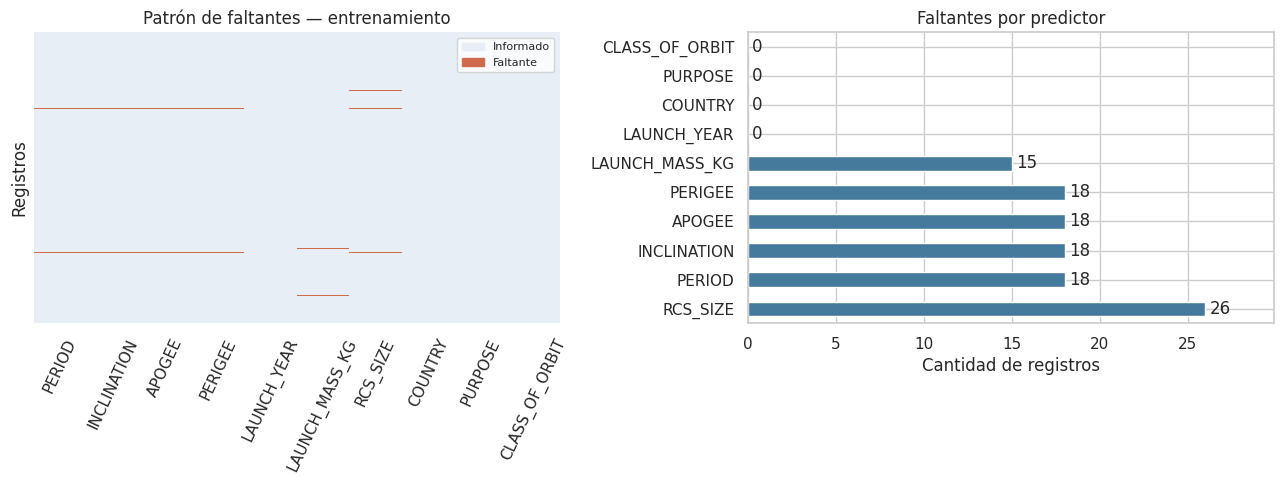

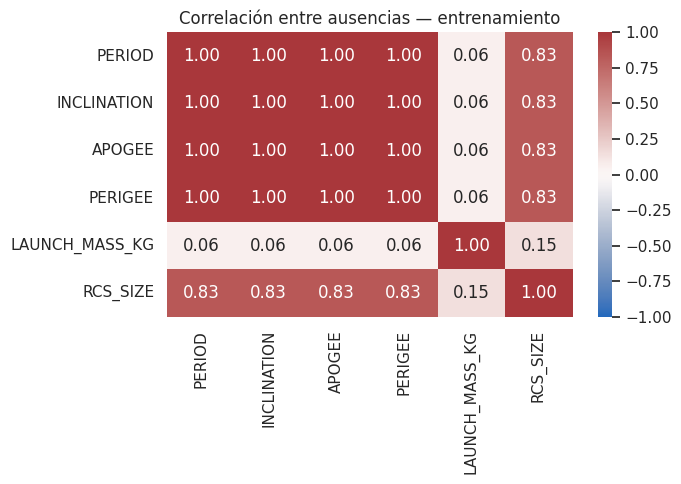

In [21]:
X_train = train_df[FEATURE_COLUMNS].copy()
X_eval = eval_df[FEATURE_COLUMNS].copy()
X_test = test_df[FEATURE_COLUMNS].copy()
y_train = train_df[TARGET].copy()
train_missing = X_train.isna().sum().sort_values(ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(X_train.isna().astype(int), ax=axes[0], cbar=False, yticklabels=False, cmap=['#e7eef5', '#cf6b4b'])
axes[0].set_title('Patrón de faltantes — entrenamiento')
axes[0].set_ylabel('Registros')
from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(color='#e7eef5', label='Informado'), Patch(color='#cf6b4b', label='Faltante')], loc='upper right', fontsize=8)
axes[0].tick_params(axis='x', rotation=65)
train_missing.plot.barh(ax=axes[1], color='#467a9d')
axes[1].set_title('Faltantes por predictor')
axes[1].set_xlabel('Cantidad de registros')
axes[1].bar_label(axes[1].containers[0], padding=3)
axes[1].set_xlim(0, train_missing.max() * 1.15)
plt.tight_layout()
plt.show()
missing_columns = X_train.columns[X_train.isna().any() & X_train.notna().any()]
if len(missing_columns) > 1:
    plt.figure(figsize=(7, 5))
    sns.heatmap(X_train[missing_columns].isna().corr(), annot=True, fmt='.2f', vmin=-1, vmax=1, cmap='vlag')
    plt.title('Correlación entre ausencias — entrenamiento')
    plt.tight_layout()
    plt.show()

### Inspección de valores extremos

Un período largo o un apogeo alto puede pertenecer a un régimen orbital válido. Los percentiles 1 y 99 se usan como diagnóstico de entrenamiento, sin descartar observaciones ni recortar la variable objetivo. Los extremos válidos permanecen también en validación y prueba.

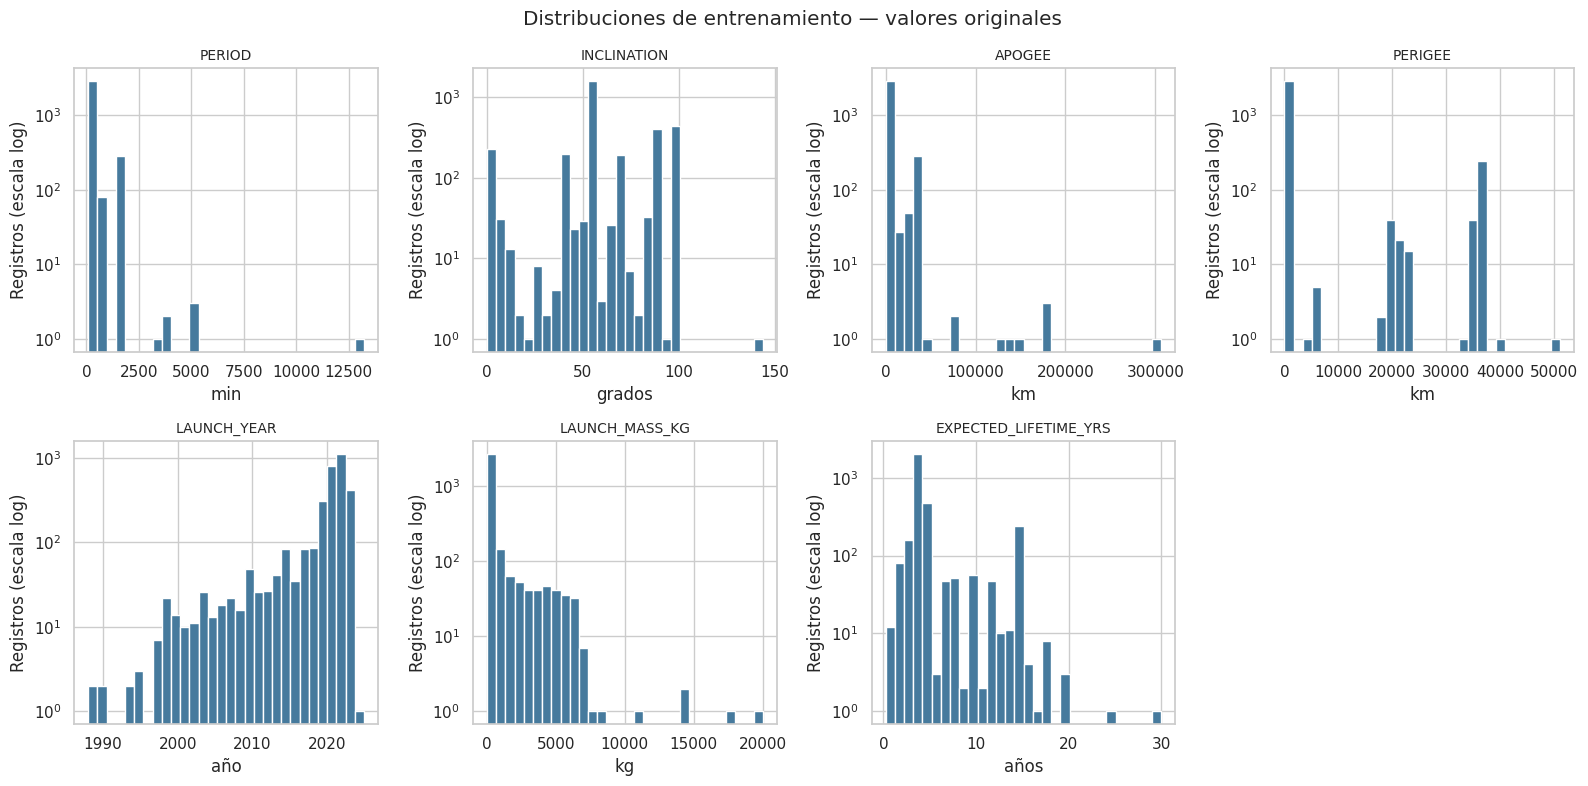

,Mínimo,P1,Mediana,P99,Máximo
PERIOD,83.81,87.364,95.59,1444.744,13234.04
INCLINATION,0.00,0.010,53.22,98.246,143.72
APOGEE,0.00,148.370,548.00,36156.630,306818.00
PERIGEE,0.00,137.000,546.00,35786.000,51094.00
LAUNCH_YEAR,1988.00,1999.000,2021.00,2023.000,2025.00
LAUNCH_MASS_KG,1.00,2.000,260.00,6181.600,20000.00
EXPECTED_LIFETIME_YRS,0.25,2.000,4.00,15.000,30.00


In [22]:
numeric_cols = NUMERIC_MEDIAN_FEATURES + ['LAUNCH_MASS_KG', TARGET]
units = {'PERIOD': 'min', 'INCLINATION': 'grados', 'APOGEE': 'km', 'PERIGEE': 'km',
         'LAUNCH_YEAR': 'año', 'LAUNCH_MASS_KG': 'kg', TARGET: 'años'}
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, column in zip(axes.flat, numeric_cols):
    values = train_df[column].dropna()
    ax.hist(values, bins=30, color='#467a9d', edgecolor='white')
    ax.set_yscale('log')
    ax.set_title(column, fontsize=10)
    ax.set_xlabel(units[column])
    ax.set_ylabel('Registros (escala log)')
axes.flat[-1].set_visible(False)
fig.suptitle('Distribuciones de entrenamiento — valores originales')
plt.tight_layout()
plt.show()
quantile_table = train_df[numeric_cols].quantile([0, .01, .5, .99, 1]).T
quantile_table.columns = ['Mínimo', 'P1', 'Mediana', 'P99', 'Máximo']
display(quantile_table.round(3))

## Imputación de datos

### Variables numéricas

Los faltantes de período, inclinación, apogeo, perigeo y año se completan con medianas aprendidas en entrenamiento. Es una aproximación estadística; no reconstruye una órbita físicamente autoconsistente.

Para la masa conservamos un imputador iterativo con `KNeighborsRegressor`, que utiliza los demás predictores ya codificados y escalados. No es la clase `KNNImputer` ni está demostrado que sea superior a la mediana: su conveniencia deberá evaluarse en TP3. **La vida útil esperada está excluida de todos los pasos del preprocesamiento.**

### Variables categóricas

Unificamos espacios y mayúsculas sin aprender de las frecuencias. Conservamos las categorías de `PURPOSE`: navegación, ciencia espacial y meteorología no se reinterpretan como comunicaciones o desarrollo tecnológico.

Los países poco frecuentes se agrupan mediante `OneHotEncoder(max_categories=5)`, ajustado sólo con entrenamiento: como máximo cuatro categorías frecuentes y una infrecuente. Las categorías desconocidas se manejan sin volver a ajustar el codificador. `PURPOSE` y `CLASS_OF_ORBIT` se codifican con one-hot, sin orden artificial.

`RCS_SIZE` sí tiene un orden SMALL < MEDIUM < LARGE. Sus faltantes se completan con la moda de entrenamiento antes de codificar; esos códigos no representan distancias físicas.

In [23]:
display(X_train['COUNTRY'].value_counts().head(10).rename('Registros de entrenamiento').to_frame())
display(X_train['PURPOSE'].value_counts().rename('Registros de entrenamiento').to_frame())
display(X_train['CLASS_OF_ORBIT'].value_counts().rename('Registros de entrenamiento').to_frame())

,Registros de entrenamiento
COUNTRY,
US,2372
UK,362
PRC,89
CIS,76
JPN,34
ESA,32
IND,30
SES,24
ORB,20


,Registros de entrenamiento
PURPOSE,
COMMUNICATIONS,2804
EARTH OBSERVATION,294
NAVIGATION/GLOBAL POSITIONING,86
SPACE SCIENCE,24
TECHNOLOGY DEVELOPMENT,18
NAVIGATION/REGIONAL POSITIONING,8
EARTH OBSERVATION/NAVIGATION,6
TECHNOLOGY DEMONSTRATION,5
EARTH SCIENCE,4


,Registros de entrenamiento
CLASS_OF_ORBIT,
LEO,2878
GEO,287
MEO,73
ELLIPTICAL,18


### Transformaciones y codificación de variables

La función `make_preprocessor` de `preprocessing.py` construye un objeto sin ajustar con las etapas: imputación simple y codificación por columnas, escalado MinMax e imputación iterativa de la masa. La lista de predictores es explícita; ni el target ni los metadatos pasan al modelo.

A continuación ajustamos una copia **sólo con `X_train`** para inspeccionar el resultado. Validación y prueba reciben únicamente `transform`. Estas matrices son una demostración y no se exportan para entrenar con validación cruzada.

In [24]:
preprocessor = make_preprocessor(random_state=RANDOM_SEED)
X_train_ready = preprocessor.fit_transform(X_train)
X_eval_ready = preprocessor.transform(X_eval)
X_test_ready = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()
assert TARGET not in FEATURE_COLUMNS
assert not any('EXPECTED_LIFETIME' in name or 'INFO_' in name for name in feature_names)
for matrix, raw in [(X_train_ready, X_train), (X_eval_ready, X_eval), (X_test_ready, X_test)]:
    assert matrix.shape == (len(raw), len(feature_names))
    assert np.isfinite(matrix).all()
train_ready_df = pd.DataFrame(X_train_ready, columns=feature_names, index=X_train.index)
display(train_ready_df.head())
print('Dimensión de los predictores transformados:', X_train_ready.shape)

Dimensión de los predictores transformados: (3256, 31)


,numeric__PERIOD,numeric__INCLINATION,numeric__APOGEE,numeric__PERIGEE,numeric__LAUNCH_YEAR,mass__LAUNCH_MASS_KG,radar__RCS_SIZE,country__COUNTRY_CIS,country__COUNTRY_PRC,country__COUNTRY_UK,country__COUNTRY_US,country__COUNTRY_infrequent_sklearn,nominal__PURPOSE_COMMUNICATIONS,nominal__PURPOSE_COMMUNICATIONS/TECHNOLOGY DEVELOPMENT,nominal__PURPOSE_EARTH OBSERVATION,nominal__PURPOSE_EARTH OBSERVATION/COMMUNICATIONS/SPACE SCIENCE,nominal__PURPOSE_EARTH OBSERVATION/NAVIGATION,nominal__PURPOSE_EARTH OBSERVATION/SPACE SCIENCE,nominal__PURPOSE_EARTH OBSERVATION/TECHNOLOGY DEVELOPMENT,nominal__PURPOSE_EARTH SCIENCE,nominal__PURPOSE_METEOROLOGICAL,nominal__PURPOSE_NAVIGATION/GLOBAL POSITIONING,nominal__PURPOSE_NAVIGATION/REGIONAL POSITIONING,nominal__PURPOSE_SPACE OBSERVATION,nominal__PURPOSE_SPACE SCIENCE,nominal__PURPOSE_TECHNOLOGY DEMONSTRATION,nominal__PURPOSE_TECHNOLOGY DEVELOPMENT,nominal__CLASS_OF_ORBIT_ELLIPTICAL,nominal__CLASS_OF_ORBIT_GEO,nominal__CLASS_OF_ORBIT_LEO,nominal__CLASS_OF_ORBIT_MEO
1479,0.052427,0.377053,0.070244,0.420871,0.810811,0.039952,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
6643,0.000935,0.487058,0.001871,0.011156,0.945946,0.014451,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
5756,0.000920,0.679516,0.001841,0.010960,0.918919,0.012951,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4444,0.000884,0.370303,0.001763,0.010549,0.918919,0.012951,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3992,0.001944,0.611606,0.003908,0.023427,0.891892,0.007350,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


### Inspección de la imputación de masa

Recuperamos las unidades originales para graficar. Comparamos la distribución observada con la de los valores imputados **en entrenamiento**; la similitud de los histogramas no valida la precisión de una imputación. Para ello haría falta ocultar valores conocidos y medir el error.

Las variables MinMax de evaluación pueden quedar fuera de [0, 1] si exceden los extremos del entrenamiento; eso no justifica volver a ajustar el escalador.

La vida útil esperada conserva sus valores originales, en años.


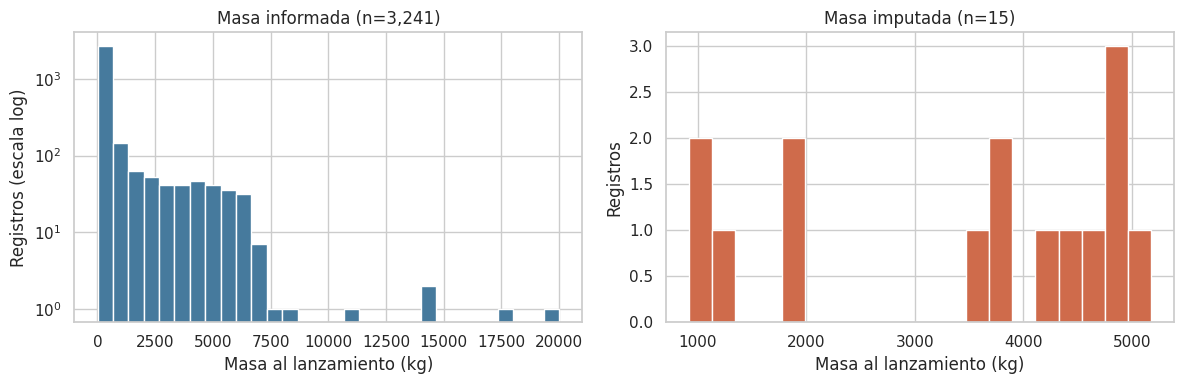

In [25]:
column_names = preprocessor.named_steps['columns'].get_feature_names_out()
mass_index = list(column_names).index('mass__LAUNCH_MASS_KG')
train_unscaled = preprocessor.named_steps['scale'].inverse_transform(X_train_ready)
mass_after = pd.Series(train_unscaled[:, mass_index], index=X_train.index)
missing_mass = X_train['LAUNCH_MASS_KG'].isna()
assert np.allclose(mass_after[~missing_mass], X_train.loc[~missing_mass, 'LAUNCH_MASS_KG'])
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(X_train.loc[~missing_mass, 'LAUNCH_MASS_KG'], bins=30, color='#467a9d', edgecolor='white')
axes[0].set_title(f'Masa informada (n={(~missing_mass).sum():,})')
axes[1].hist(mass_after[missing_mass], bins=20, color='#cf6b4b', edgecolor='white')
axes[1].set_title(f'Masa imputada (n={missing_mass.sum():,})')
for ax in axes:
    ax.set_xlabel('Masa al lanzamiento (kg)')
    ax.set_ylabel('Registros')
axes[0].set_yscale('log')
axes[0].set_ylabel('Registros (escala log)')
plt.tight_layout()
plt.show()
assert y_train.equals(train_df[TARGET])
print('La vida útil esperada conserva sus valores originales, en años.')

## Reporte exploratorio final de los datos

Comprobamos tamaño, trazabilidad y ausencia de faltantes en las matrices transformadas. Los CSV conservan los faltantes de entrada de forma deliberada. El reporte inicial y el final describen poblaciones distintas (PAYLOAD integrado frente a entrenamiento); no interpretamos la diferencia como una mejora de cobertura.

La curación no evalúa desempeño predictivo. Las métricas de TP3 deberán calcularse de nuevo con estos conjuntos y el preprocesamiento dentro de cada fold.

In [26]:
processing_summary = pd.DataFrame({
    'Registros': {name: len(frame) for name, frame in data_dic.items()},
    'Target informado': {name: int(frame[TARGET].notna().sum()) for name, frame in data_dic.items()},
    'Faltantes en X sin transformar': {name: int(frame[FEATURE_COLUMNS].isna().sum().sum()) for name, frame in data_dic.items()},
    'Faltantes en X transformado': {name: int(np.isnan(matrix).sum()) for name, matrix in zip(data_dic, [X_train_ready, X_eval_ready, X_test_ready])},
})
display(processing_summary)
save_report('TP2 — Reporte exploratorio final',
            {'Particiones': split_summary, 'Verificaciones': processing_summary,
             'Predictores de entrenamiento': data_summary(X_train), 'Extremos de entrenamiento': quantile_table},
            'TP2_ReporteExploratorioDeDatosFinal.html',
            'Datos etiquetados con vida útil UCS original. Transformaciones ajustadas sólo con entrenamiento; sin evaluación de modelos.')

,Registros,Target informado,Faltantes en X sin transformar,Faltantes en X transformado
Entrenamiento,3256,3256,113,0
Evaluacion,1086,1086,43,0
Prueba,1086,1086,40,0


## Generación de datasets finales

Exportamos los tres conjuntos supervisados sin transformar (60/20/20), los registros sin etiqueta y el catálogo PAYLOAD curado completo para exploración no supervisada. Todos preservan el identificador NORAD, las unidades y los faltantes originales válidos. Ninguna fila sin etiqueta puede entrar en las métricas supervisadas.

`TP2_manifest.json` documenta fuentes, hashes, semilla, columnas, tamaños y verificaciones. Para clustering, seleccionar variables físicas y definir su propio preprocesamiento; el catálogo completo contiene también objetos reservados para test supervisado, por lo que no debe usarse para decidir el modelo supervisado.

En TP3 hay que leer estos CSV locales y usar un `Pipeline` que contenga `make_preprocessor()` y el clasificador. Los CSV antiguos publicados en `jalbiero/unc-space-debris-datasets@v2.0.0` corresponden a otra preparación y sus métricas no validan estos conjuntos.

In [27]:
exports = {f'TP2_DatosDe{name}.csv': frame for name, frame in data_dic.items()}
exports['TP2_DatosSinEtiqueta.csv'] = unlabeled_df
exports['TP2_CatalogoCurado.csv'] = clean_df
export_info = {}
source_targets = clean_df.set_index('INFO_NORAD_NUMBER')[TARGET]
for filename, frame in exports.items():
    destination = PROJECT_DIR / filename
    ordered = frame.sort_values('INFO_NORAD_NUMBER').reset_index(drop=True)
    ordered.to_csv(destination, index=False, float_format='%.15g')
    restored = pd.read_csv(destination)
    assert restored['INFO_NORAD_NUMBER'].is_unique
    expected = restored['INFO_NORAD_NUMBER'].map(source_targets)
    assert np.allclose(restored[TARGET], expected, equal_nan=True)
    export_info[filename] = {'rows': len(restored), 'sha256': hashlib.sha256(destination.read_bytes()).hexdigest()}

manifest = {
    'schema_version': 3, 'source_commit': DATA_COMMIT, 'source_url': DATA_URL,
    'source_sha256': EXPECTED_SHA256, 'random_seed': RANDOM_SEED,
    'population': 'PAYLOAD con coincidencia UCS, catálogo histórico',
    'target': TARGET, 'target_units': 'años', 'target_imputed': False,
    'features': FEATURE_COLUMNS, 'exports_preprocessed': False,
    'split': 'aleatorio por NORAD, aproximadamente 60/20/20; no independiente por familia ni temporal',
    'learned_preprocessing': 'make_preprocessor: ajustar dentro de cada fold en TP3',
    'rows_payload': len(clean_df), 'rows_labeled': len(labeled_df), 'rows_unlabeled': len(unlabeled_df),
    'invalid_values_to_missing': invalid_counts,
    'checks': {'disjoint_supervised_ids': True, 'all_supervised_targets_observed': True,
               'target_excluded_from_preprocessor': True, 'finite_transformed_features': True},
    'files': export_info,
}
(PROJECT_DIR / 'TP2_manifest.json').write_text(json.dumps(manifest, ensure_ascii=False, indent=2) + '\n', encoding='utf-8')
display(pd.DataFrame(export_info).T[['rows']].rename(columns={'rows': 'Filas exportadas'}))

,Filas exportadas
TP2_DatosDeEntrenamiento.csv,3256
TP2_DatosDeEvaluacion.csv,1086
TP2_DatosDePrueba.csv,1086
TP2_DatosSinEtiqueta.csv,1941
TP2_CatalogoCurado.csv,7369


## Conclusiones y conexión con el modelado

- La unión por NORAD tiene cobertura y discrepancias explícitas; la población se restringe a PAYLOAD.
- La vida útil esperada informada por UCS se conserva en años y nunca se imputa. Los registros sin etiqueta quedan disponibles por separado.
- Los valores extremos válidos se conservan. Los análisis de distribuciones e imputación usan entrenamiento.
- Imputadores, categorías por frecuencia y escalador se ajustan sólo en `fit`; validación y prueba se transforman con esos parámetros.
- Los CSV sin transformar permiten incorporar el preprocesamiento al Pipeline de cada fold. El archivo de metadatos identifica exactamente los insumos y resultados exportados.

La siguiente etapa debe reevaluar clasificación y clustering, explicitar los límites de las clases y distinguir generalización dentro del catálogo de generalización a familias o años nuevos.